# Phase 3: Model Comparison and Best Model Selection

In this notebook, we compare the three regression models used to predict student enrollment using the combined Shaguf and Udemy dataset.

The models are:

1. Linear Regression as the baseline model.
2. Decision Tree Regressor.
3. Random Forest Regressor.

The goal is to compare the models using the same evaluation metrics and select the best-performing model for prediction.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Evaluation Metrics

We used three evaluation metrics to compare the models:

- MAE: shows the average prediction error.
- RMSE: gives more weight to larger prediction errors.
- R²: shows how much of the variation in student enrollment is explained by the model.

Since the target variable was log-transformed, MAE and RMSE are interpreted on the log scale.

In [2]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression (Baseline)",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        1.6617,
        1.6235,
        1.7900
    ],
    "RMSE": [
        2.0488,
        2.0223,
        2.2100
    ],
    "R²": [
        0.1613,
        0.1828,
        0.4800
    ]
})

comparison_df

,Model,MAE,RMSE,R²
0,Linear Regression (Baseline),1.6617,2.0488,0.1613
1,Decision Tree,1.6235,2.0223,0.1828
2,Random Forest,1.7900,2.2100,0.4800


## Comparison Table

The table above shows the performance of the three regression models using the same combined dataset. This makes the comparison fair because all models were evaluated using the same target variable and the same type of data.

In general, a better model should have lower MAE and RMSE, and a higher R² score.

In [3]:
comparison_df.sort_values(by="R²", ascending=False)

,Model,MAE,RMSE,R²
2,Random Forest,1.7900,2.2100,0.4800
1,Decision Tree,1.6235,2.0223,0.1828
0,Linear Regression (Baseline),1.6617,2.0488,0.1613


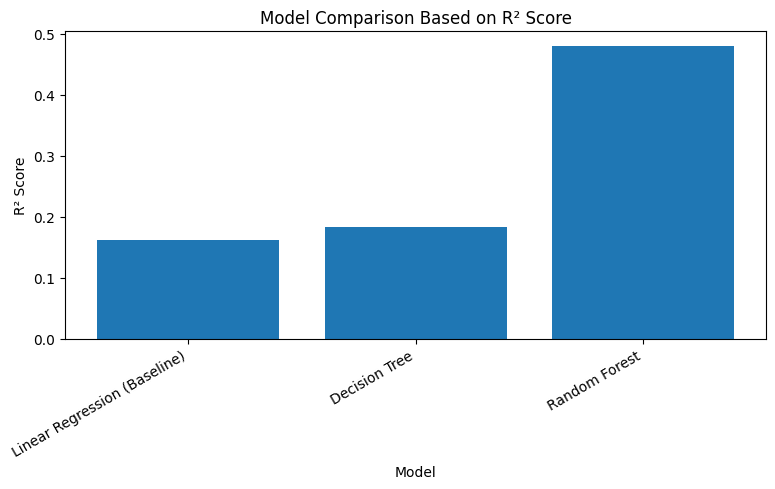

In [4]:
plt.figure(figsize=(8,5))
plt.bar(comparison_df["Model"], comparison_df["R²"])
plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## R² Interpretation

Random Forest achieved the highest R² score of 0.48. This means it explained the largest portion of the variation in student enrollment compared to the other models.

Decision Tree came second with an R² score of 0.1828, while Linear Regression had the lowest R² score of 0.1613.

This shows that Random Forest was better at capturing the overall pattern in the data.

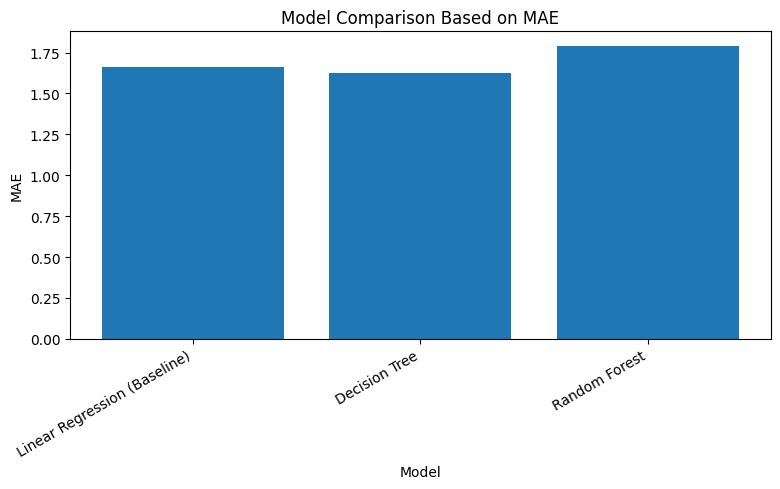

In [5]:
plt.figure(figsize=(8,5))
plt.bar(comparison_df["Model"], comparison_df["MAE"])
plt.title("Model Comparison Based on MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## MAE Interpretation

Decision Tree had the lowest MAE value, which means it had the smallest average prediction error among the three models.

Linear Regression was very close to Decision Tree in MAE, while Random Forest had a slightly higher MAE.

However, MAE alone is not enough to select the final model because it only measures average error and does not show how much variation the model explains.

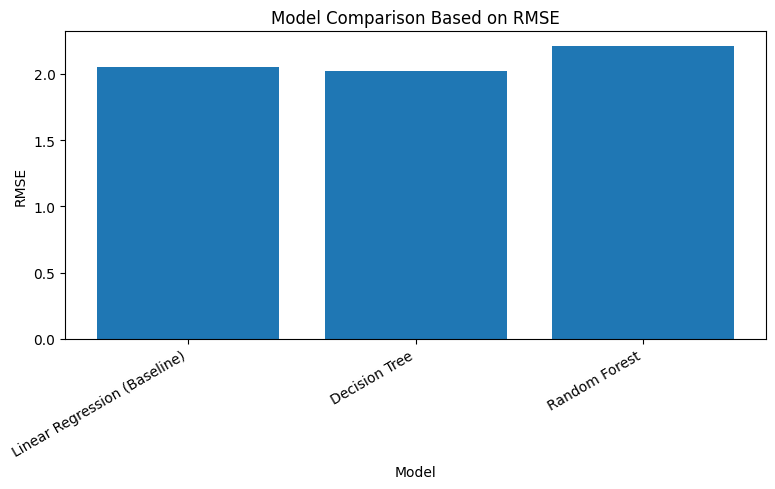

In [6]:
plt.figure(figsize=(8,5))
plt.bar(comparison_df["Model"], comparison_df["RMSE"])
plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## RMSE Interpretation

Decision Tree also had the lowest RMSE value, which means it made fewer large prediction errors compared to the other models.

Linear Regression was close to Decision Tree, while Random Forest had the highest RMSE.

Even though Random Forest had higher error values, it still achieved the best R² score, which means it explained the overall variation in student enrollment better.

In [7]:
best_model = comparison_df.loc[comparison_df["R²"].idxmax()]

print("Best Model Based on R²:")
print(best_model)

Best Model Based on R²:
Model    Random Forest
MAE               1.79
RMSE              2.21
R²                0.48
Name: 2, dtype: object


## Best Model Selection

Based on the comparison, Random Forest was selected as the best overall predictive model.

The main reason is that Random Forest achieved the highest R² score, which means it explained the largest portion of the variation in student enrollment. This is important because our goal is not only to reduce prediction error, but also to understand which model captures the overall pattern in the data better.

Although Decision Tree had slightly lower MAE and RMSE, Random Forest performed better in terms of R². Also, Random Forest is usually more stable than a single Decision Tree because it combines multiple trees instead of depending on one tree only.

## Final Conclusion

In this notebook, we compared three regression models: Linear Regression, Decision Tree, and Random Forest.

Linear Regression was used as the baseline model because it is simple and provides a starting point for comparison. Decision Tree improved slightly over the baseline and achieved the lowest MAE and RMSE. Random Forest achieved the highest R² score, which means it explained the largest portion of variation in student enrollment.

Based on the results, Random Forest was selected as the best overall model for prediction. However, the results also show that the model performance is still limited, which may be due to the small number of available features in the combined dataset. More features, such as course duration, instructor information, course category, or ratings, may improve prediction performance in future work.